In [31]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import *
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyRegressor, LazyClassifier
from scipy.stats import randint, uniform, zscore, stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error, accuracy_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import TargetEncoder
from sklearn import linear_model
from sklearn.linear_model import Lasso, LogisticRegression, LinearRegression
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.compose import ColumnTransformer
import joblib
import warnings

In [4]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')
pd.set_option('display.max_columns',None)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [5]:
var_cero = ['Glucose','BloodPressure','BMI','Insulin']
df[var_cero] == 0
df[var_cero] = df[var_cero].replace(0,np.nan)

Train Test Split

In [6]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
imputer = MissForest()

X_train_imp = imputer.fit_transform(X_train)
X_train_imp

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 97.69it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
60,2,0,0.30,21,84.00,28.24,69.85,111.18
618,9,24,1.28,50,112.00,28.20,82.00,169.58
346,1,19,0.65,22,139.00,28.70,46.00,83.00
294,0,0,0.25,65,161.00,21.90,50.00,240.72
231,6,37,0.24,46,134.00,46.20,80.00,370.00
...,...,...,...,...,...,...,...,...
71,5,35,0.41,26,139.00,28.60,64.00,140.00
106,1,0,0.21,27,96.00,22.40,122.00,98.70
270,10,37,1.14,38,101.00,45.60,86.00,119.07
435,0,0,0.20,29,141.00,42.40,73.71,117.73


In [9]:
X_test_imp = imputer.transform(X_test)
X_test_imp

 60%|██████    | 3/5 [00:00<00:00, 70.43it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
668,6,33,0.43,43,98.00,34.00,58.00,190.00
324,2,32,0.15,21,112.00,35.70,75.00,168.19
624,2,0,0.16,21,108.00,30.80,64.00,145.49
690,8,0,0.86,34,107.00,24.60,80.00,140.03
473,7,0,0.21,50,136.00,29.90,90.00,142.22
...,...,...,...,...,...,...,...,...
355,9,0,0.30,49,165.00,30.40,88.00,116.72
534,1,30,1.25,24,77.00,33.30,56.00,56.00
344,8,0,0.48,57,95.00,36.80,72.00,142.68
296,2,38,0.34,29,146.00,28.00,70.00,360.00


Feature Importance

In [10]:
#Metodo1

model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1).fit(X_train_imp,y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

#Convertir a dataframe
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

#importancia acumulada
df_rf_imp['rf_importance_accum'] = df_rf_imp['rf_importance'].cumsum()

df_rf_imp


,feature,rf_importance,rf_importance_accum
4,Insulin,22.42,22.42
7,Age,15.93,38.35
5,BMI,15.18,53.53
3,SkinThickness,13.51,67.04
2,BloodPressure,11.03,78.06
6,DiabetesPedigreeFunction,7.78,85.85
0,Pregnancies,7.26,93.11
1,Glucose,6.89,100.00


In [11]:
#METODO 2
#XGBClassifier

#crear conjunto de val
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp,y_train, test_size=0.2,random_state=42)

#ajustar modelo

model_xgb = XGBClassifier(objective='binary:logistic',random_state=42).fit(X_train1,y_train1)

#10 permutaciones por caract

perm = permutation_importance(model_xgb,X_val,y_val,n_repeats=10,random_state=42,n_jobs=-1,scoring='recall')
df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
4,Insulin,16.67
5,BMI,5.00
3,SkinThickness,4.76
0,Pregnancies,3.10
1,Glucose,2.38
7,Age,1.90
2,BloodPressure,1.19
6,DiabetesPedigreeFunction,0.48


In [12]:
#metodo3: Shap

#METODO 3: usar SHAP

model_lgbm = lgb.LGBMClassifier(random_state=42,n_jobs=-1).fit(X_train1,y_train1)

explainer = shap.Explainer(model_lgbm,X_val)
shap_vals = explainer(X_val,check_additivity=False).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
4,Glucose,25.72
3,Age,16.64
5,BMI,15.43
7,Insulin,12.48
2,DiabetesPedigreeFunction,11.16
6,BloodPressure,8.77
1,SkinThickness,5.54
0,Pregnancies,4.26


In [13]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,16.67,12.48
0,Age,15.93,38.35,1.90,16.64
1,BMI,15.18,53.53,5.00,15.43
7,SkinThickness,13.51,67.04,4.76,5.54
2,BloodPressure,11.03,78.06,1.19,8.77
3,DiabetesPedigreeFunction,7.78,85.85,0.48,11.16
6,Pregnancies,7.26,93.11,3.10,4.26
4,Glucose,6.89,100.00,2.38,25.72


In [14]:
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm_imp']>=1)&(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,16.67,12.48
0,Age,15.93,38.35,1.90,16.64
1,BMI,15.18,53.53,5.00,15.43
7,SkinThickness,13.51,67.04,4.76,5.54
2,BloodPressure,11.03,78.06,1.19,8.77
6,Pregnancies,7.26,93.11,3.10,4.26
4,Glucose,6.89,100.00,2.38,25.72


In [15]:
features = df_filt['feature']
features

5          Insulin
0              Age
1              BMI
7    SkinThickness
2    BloodPressure
6      Pregnancies
4          Glucose
Name: feature, dtype: object

Modelado

In [16]:
X_train_sel = X_train_imp[features]
X_test_sel = X_test_imp[features]

In [17]:
#Modelo 1: 
model1 = XGBClassifier(random_state=42)
model1.fit(X_train_sel,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
y_pred = model1.predict(X_test_sel)

In [19]:
accuracy_score(y_test,y_pred)

0.7272727272727273

In [20]:
#Modelo 2: 
model2 = XGBClassifier(n_estimators=5, learning_rate=0.4, max_depth=5, min_samples_leaf=7,gamma= 0.8,max_features=X_train.shape[1]//2,random_state=42)
model2.fit(X_train_sel,y_train)

#larning rate: 0.4

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
y_pred2 = model2.predict(X_test_sel)

In [22]:
accuracy_score(y_test,y_pred2)

0.7922077922077922

Para este ejercicio se hizo búsqueda de hiper parámetros, pero al entrenar el modelo con los parámetros sugeridos, el rendimiento fue menor, así que obviaremos esta parte y seleccionaremos el modelo 2. 

In [23]:
#Busqueda extensiva
# param_dist = {
#     'n_estimators': randint(1, 20),
#     'learning_rate': uniform(0.01, 0.9),
#     'max_depth': randint(-1, 20),
#     'min_samples_leaf': randint(5, 50),
#     'gamma': randint(0,1),
#     'subsample': randint(0,1)
# }

# model = XGBClassifier(random_state=42)

# # RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     n_iter=5,                  # Número de combinaciones aleatorias a probar
#     scoring='accuracy',
#     cv=5,
#     verbose=4,
#     n_jobs=-1,
#     random_state=123
# )

# random_search.fit(X_train_sel, y_train1)

# print("Mejores hiperparámetros:")
# print(random_search.best_params_)

# best_model = random_search.best_estimator_


In [24]:
# train_pred_best = best_model.predict(X_train_sel)
# test_pred_best = best_model.predict(X_test_sel)

In [25]:
# accuracy_score(y_test,test_pred_best)

In [26]:
#Busqueda intensiva

# param_grid = {
#     'learning_rate': [0.5, 0.6, 0.63, 0.7, 0.8],
#     'max_depth': [1, 2, 3, 4],
#     'n_estimators': [3, 5, 10, 15, 20],
#     'min_samples_leaf': [25, 30, 33, 35, 40],
#     'subsample': [0.5, 0.6, 0.7, 0.8],
#     'gamma': [0, 0.1, 0.2]}

# # GridSearchCV
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='accuracy',
#     cv=3,
#     verbose=2,
#     n_jobs=-1
# )

# # Ajuste
# grid_search.fit(X_train_sel, y_train)

# print("Mejores hiperparámetros:")
# print(grid_search.best_params_)

# best_model2 = grid_search.best_estimator_

In [27]:
# train_pred_best2 = best_model2.predict(X_train_sel)
# test_pred_best2 = best_model2.predict(X_test_sel)

In [28]:
# accuracy_score(y_test,test_pred_best2)

In [29]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84        99
           1       0.73      0.65      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



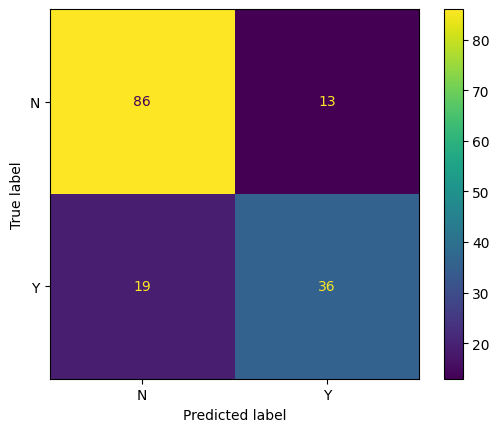

In [30]:
#Matriz modelo seleccionado
cm = confusion_matrix(y_test, y_pred2)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

Tras evaluar los tres algoritmos, se descarta el Decision Tree por evidencia de sobreajuste (overfitting). Al comparar Random Forest y XGBoost, ambos presentan un Accuracy idéntico (79%); sin embargo, el XGBoost demuestra una superioridad clínica crítica al alcanzar un Recall del 65% frente al 56% del Random Forest. En un entorno médico, maximizar el Recall es prioritario para minimizar los falsos negativos

In [32]:
warnings.filterwarnings('ignore',message='findfont')